In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output


from rescue_bot.env import RescueBotEnv
from rescue_bot.policy import PolicyNet, reinforce_update

In [2]:
def train_agent(env, num_episodes=2000, gamma=0.99, lr=1e-3):
    policy = PolicyNet(obs_size=env.obs_size, n_actions=env.n_actions)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    # Historique pour les tracés
    history = {
        "rewards": [],
        "rescued": [],
        "steps": [],
        "losses": []
    }
    
    for episode in range(num_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []
        done = False
        
        while not done:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            action_mask = torch.tensor(env.get_action_mask(), dtype=torch.bool).unsqueeze(0)
            
            dist = policy(obs_tensor, action_mask)
            action = dist.sample()
            
            log_probs.append(dist.log_prob(action))
            obs, reward, done, info = env.step(action.item())
            rewards.append(reward)
            
        loss = reinforce_update(policy, optimizer, log_probs, rewards, gamma)
        
        # Enregistrement des statistiques
        history["rewards"].append(sum(rewards))
        history["rescued"].append(env.rescued)
        history["steps"].append(env.steps)
        history["losses"].append(loss)
        
        # Affichage dynamique tous les 100 épisodes
        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{num_episodes} | Moyenne Reward (100 derniers): {np.mean(history['rewards'][-100:]):.1f} | Evacués max: {np.max(history['rescued'][-100:])}")
            
    return policy, history

# Lancer l'entraînement
env = RescueBotEnv()
trained_policy, training_history = train_agent(env, num_episodes=1500)

Episode 100/1500 | Moyenne Reward (100 derniers): -271.9 | Evacués max: 3
Episode 200/1500 | Moyenne Reward (100 derniers): -244.7 | Evacués max: 3
Episode 300/1500 | Moyenne Reward (100 derniers): -305.8 | Evacués max: 3
Episode 400/1500 | Moyenne Reward (100 derniers): -244.6 | Evacués max: 2
Episode 500/1500 | Moyenne Reward (100 derniers): -253.8 | Evacués max: 3
Episode 600/1500 | Moyenne Reward (100 derniers): -452.8 | Evacués max: 1
Episode 700/1500 | Moyenne Reward (100 derniers): -261.8 | Evacués max: 2
Episode 800/1500 | Moyenne Reward (100 derniers): -257.3 | Evacués max: 2
Episode 900/1500 | Moyenne Reward (100 derniers): -289.1 | Evacués max: 2
Episode 1000/1500 | Moyenne Reward (100 derniers): -265.6 | Evacués max: 2
Episode 1100/1500 | Moyenne Reward (100 derniers): -240.9 | Evacués max: 2
Episode 1200/1500 | Moyenne Reward (100 derniers): -261.8 | Evacués max: 2
Episode 1300/1500 | Moyenne Reward (100 derniers): -291.6 | Evacués max: 2
Episode 1400/1500 | Moyenne Reward

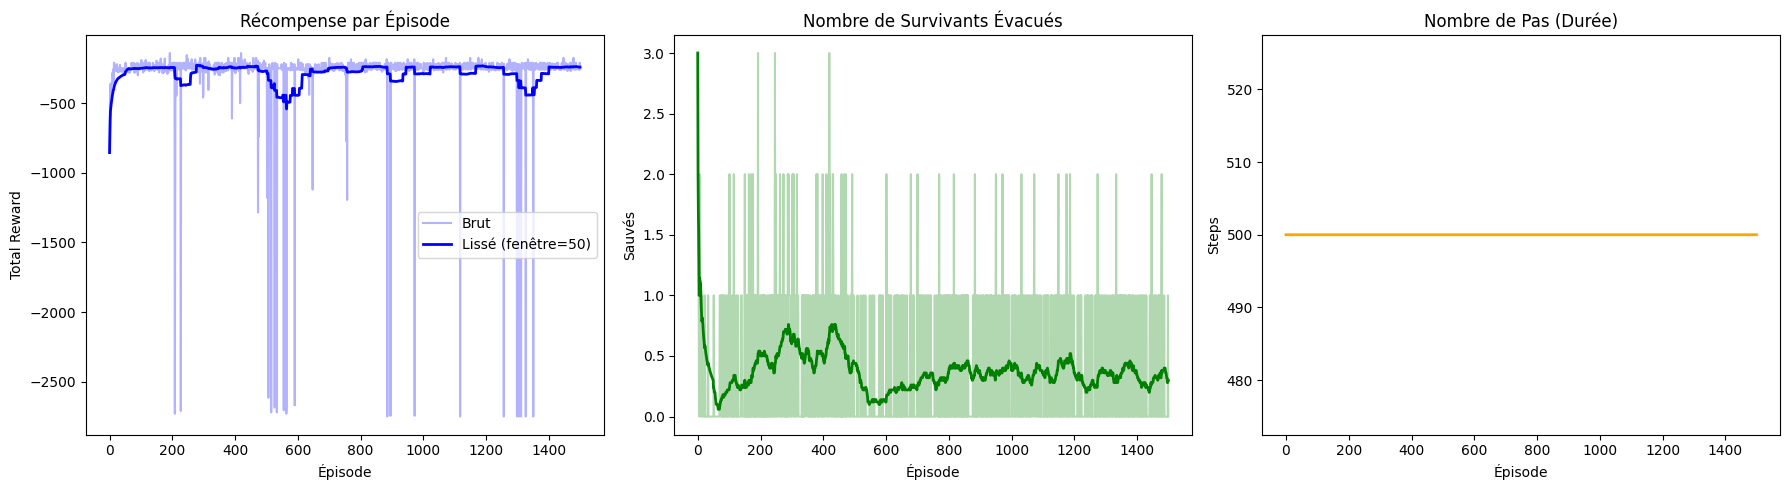

In [3]:
def plot_training(history, window=50):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Lissage avec Pandas
    df = pd.DataFrame(history)
    smoothed = df.rolling(window, min_periods=1).mean()
    
    # Courbe 1 : Récompenses
    axs[0].plot(df["rewards"], alpha=0.3, color='blue', label='Brut')
    axs[0].plot(smoothed["rewards"], color='blue', linewidth=2, label=f'Lissé (fenêtre={window})')
    axs[0].set_title("Récompense par Épisode")
    axs[0].set_xlabel("Épisode")
    axs[0].set_ylabel("Total Reward")
    axs[0].legend()
    
    # Courbe 2 : Nombre de sauvés
    axs[1].plot(df["rescued"], alpha=0.3, color='green')
    axs[1].plot(smoothed["rescued"], color='green', linewidth=2)
    axs[1].set_title("Nombre de Survivants Évacués")
    axs[1].set_xlabel("Épisode")
    axs[1].set_ylabel("Sauvés")
    
    # Courbe 3 : Durée des épisodes
    axs[2].plot(df["steps"], alpha=0.3, color='orange')
    axs[2].plot(smoothed["steps"], color='orange', linewidth=2)
    axs[2].set_title("Nombre de Pas (Durée)")
    axs[2].set_xlabel("Épisode")
    axs[2].set_ylabel("Steps")
    
    plt.tight_layout()
    plt.show()

plot_training(training_history)

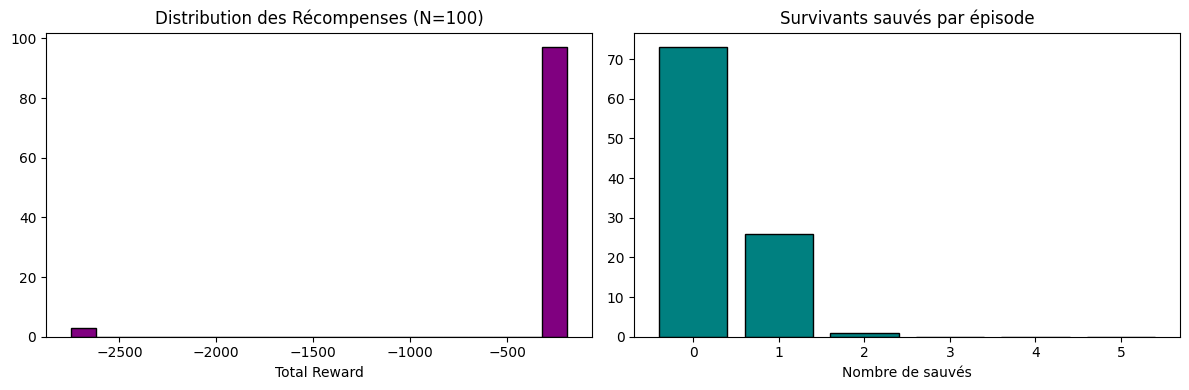

Moyenne de récompense : -317.7 ± 428.1
Taux de succès total (5/5) : 0.0%


In [4]:
def evaluate_agent(env, policy, num_eval_episodes=100):
    eval_rewards = []
    eval_rescued = []
    
    with torch.no_grad(): # Pas de calcul de gradients pour l'évaluation
        for _ in range(num_eval_episodes):
            obs = env.reset()
            done = False
            ep_reward = 0
            
            while not done:
                obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                action_mask = torch.tensor(env.get_action_mask(), dtype=torch.bool).unsqueeze(0)
                
                # En évaluation, on peut prendre l'action la plus probable (argmax) 
                # plutôt que d'échantillonner (sample) pour moins de variance
                dist = policy(obs_tensor, action_mask)
                action = torch.argmax(dist.probs) 
                
                obs, reward, done, _ = env.step(action.item())
                ep_reward += reward
                
            eval_rewards.append(ep_reward)
            eval_rescued.append(env.rescued)
            
    # Tracé des résultats d'évaluation
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    axs[0].hist(eval_rewards, bins=20, color='purple', edgecolor='black')
    axs[0].set_title(f"Distribution des Récompenses (N={num_eval_episodes})")
    axs[0].set_xlabel("Total Reward")
    
    # Histogramme discret pour les survivants (0 à 5)
    bins = np.arange(env.NUM_SURVIVORS + 2) - 0.5 
    axs[1].hist(eval_rescued, bins=bins, color='teal', edgecolor='black', rwidth=0.8)
    axs[1].set_title("Survivants sauvés par épisode")
    axs[1].set_xlabel("Nombre de sauvés")
    axs[1].set_xticks(range(env.NUM_SURVIVORS + 1))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Moyenne de récompense : {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}")
    print(f"Taux de succès total ({env.NUM_SURVIVORS}/{env.NUM_SURVIVORS}) : {np.mean(np.array(eval_rescued) == env.NUM_SURVIVORS)*100:.1f}%")

evaluate_agent(env, trained_policy)